# Midterm Exam - Model Comparison - Matthew Shaver

This notebook loads the saved Model A, Model B, and SRGAN checkpoints. It compares Model A on original test images with Model B on SRGAN-generated test images from the same test records. No models are trained in this notebook.

## Setup

Load the libraries and locate the three saved checkpoints used in the comparison.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from PIL import Image
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import mobilenet_v2

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'notebooks').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / 'notebooks').exists():
    raise FileNotFoundError('Open this notebook from the project repository.')

print('PyTorch version:', torch.__version__)
print('Project root:', PROJECT_ROOT)

PyTorch version: 2.1.2+cu121
Project root: C:\Users\Matt Shaver\OneDrive\Desktop\DSBA-6165-Sum-2026-Take-Home-Exam


In [2]:
SEED = 42
LOW_RESOLUTION_SIZE = 32
IMAGE_SIZE = 128
BATCH_SIZE = 32
NUM_WORKERS = 0
CLASS_NAMES = ('cats', 'dogs')
BOOTSTRAP_SAMPLES = 1000

SPLIT_DIR = PROJECT_ROOT / 'data' / 'splits'
MODELS_DIR = PROJECT_ROOT / 'models'
MODEL_A_PATH = MODELS_DIR / 'model_a_mobilenetv2_best.pt'
MODEL_B_PATH = MODELS_DIR / 'model_b_srgan_mobilenetv2_best.pt'
SRGAN_PATH = MODELS_DIR / 'srgan' / 'last.pt'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'model_comparison'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

missing_files = []
for model_path in [MODEL_A_PATH, MODEL_B_PATH, SRGAN_PATH]:
    if not model_path.exists():
        missing_files.append(str(model_path))

if missing_files:
    print('Missing saved model files:')
    for missing_file in missing_files:
        print(missing_file)
    print('Warning: some model files are missing. Downstream cells will fail.')

np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PIN_MEMORY = DEVICE.type == 'cuda'

print('Device:', DEVICE)
print('Model A:', MODEL_A_PATH)
print('Model B:', MODEL_B_PATH)
print('SRGAN:', SRGAN_PATH)

Device: cuda
Model A: C:\Users\Matt Shaver\OneDrive\Desktop\DSBA-6165-Sum-2026-Take-Home-Exam\models\model_a_mobilenetv2_best.pt
Model B: C:\Users\Matt Shaver\OneDrive\Desktop\DSBA-6165-Sum-2026-Take-Home-Exam\models\model_b_srgan_mobilenetv2_best.pt
SRGAN: C:\Users\Matt Shaver\OneDrive\Desktop\DSBA-6165-Sum-2026-Take-Home-Exam\models\srgan\last.pt


## Prepare Test Data

Each test record is loaded as an original 128x128 image and a matching 32x32 input for the SRGAN.

In [3]:
test_table = pd.read_csv(SPLIT_DIR / 'test_split.csv')
class_counts = test_table['label'].value_counts().sort_index()

if set(class_counts.index) != set(CLASS_NAMES):
    raise ValueError('Test split must contain cats and dogs.')

print('Test images:', len(test_table))
print(class_counts)

image_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

Test images: 7479
label
cats    3741
dogs    3738
Name: count, dtype: int64


In [4]:
class PairedImageDataset(Dataset):
    def __init__(self, records):
        self.records = records.reset_index(drop=True)
        self.class_to_index = {'cats': 0, 'dogs': 1}

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        record = self.records.iloc[index]

        with Image.open(record['image_path']) as image:
            image = image.convert('RGB')

        original_image = image.resize((IMAGE_SIZE, IMAGE_SIZE), Image.BICUBIC)
        low_resolution = original_image.resize(
            (LOW_RESOLUTION_SIZE, LOW_RESOLUTION_SIZE),
            Image.BICUBIC,
        )
        label = self.class_to_index[record['label']]

        low_resolution = image_transform(low_resolution)
        original_image = image_transform(original_image)
        label = torch.tensor(label, dtype=torch.float32)

        return low_resolution, original_image, label, index


test_dataset = PairedImageDataset(test_table)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print('Test batches:', len(test_loader))

Test batches: 234


## Load Saved Models

Load the two trained MobileNetV2 classifiers and the trained SRGAN generator.

In [5]:
class MobileNetV2Classifier(nn.Module):
    def __init__(self, weights):
        super().__init__()
        self.model = mobilenet_v2(weights=weights)

        for parameter in self.model.features.parameters():
            parameter.requires_grad = False

        input_features = self.model.classifier[1].in_features
        self.model.classifier[1] = nn.Linear(input_features, 1)

    def forward(self, images):
        return self.model(images).squeeze(1)


class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
            nn.PReLU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
        )

    def forward(self, images):
        return images + self.layers(images)


class Generator(nn.Module):
    def __init__(self, residual_blocks=4):
        super().__init__()
        self.initial = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=9, padding=4),
            nn.PReLU(),
        )
        self.residuals = nn.Sequential(
            *[ResidualBlock(64) for _ in range(residual_blocks)]
        )
        self.after_residuals = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
        )
        self.upsample = nn.Sequential(
            nn.Conv2d(64, 256, kernel_size=3, padding=1),
            nn.PixelShuffle(2),
            nn.PReLU(),
            nn.Conv2d(64, 256, kernel_size=3, padding=1),
            nn.PixelShuffle(2),
            nn.PReLU(),
        )
        self.output = nn.Sequential(
            nn.Conv2d(64, 3, kernel_size=9, padding=4),
            nn.Tanh(),
        )

    def forward(self, images):
        initial_features = self.initial(images)
        features = self.after_residuals(self.residuals(initial_features))
        return self.output(self.upsample(features + initial_features))

In [6]:
generator = Generator().to(DEVICE)
srgan_checkpoint = torch.load(SRGAN_PATH, map_location=DEVICE)
generator.load_state_dict(srgan_checkpoint['generator_state_dict'])
generator.eval()

model_a = MobileNetV2Classifier(weights=None).to(DEVICE)
model_a.load_state_dict(torch.load(MODEL_A_PATH, map_location=DEVICE))
model_a.eval()

model_b = MobileNetV2Classifier(weights=None).to(DEVICE)
model_b.load_state_dict(torch.load(MODEL_B_PATH, map_location=DEVICE))
model_b.eval()

print('Loaded Model A')
print('Loaded Model B')
print('Loaded SRGAN checkpoint from epoch:', srgan_checkpoint['epoch'])

Loaded Model A
Loaded Model B
Loaded SRGAN checkpoint from epoch: 150


## Paired Test Evaluation

The primary assignment comparison is Model A on original images versus Model B on SRGAN images. The two off-diagonal combinations are also measured to separate the effect of classifier training from the effect of the image domain.

In [7]:
model_a_original_probabilities = []
model_a_srgan_probabilities = []
model_b_original_probabilities = []
model_b_srgan_probabilities = []
targets = []
test_indices = []

model_a.eval()
model_b.eval()
generator.eval()

with torch.no_grad():
    for low_resolution, original_images, labels, indices in test_loader:
        low_resolution = low_resolution.to(DEVICE, non_blocking=True)
        original_images = original_images.to(DEVICE, non_blocking=True)
        generated_images = generator(low_resolution)

        model_a_original = torch.sigmoid(model_a(original_images))
        model_a_srgan = torch.sigmoid(model_a(generated_images))
        model_b_original = torch.sigmoid(model_b(original_images))
        model_b_srgan = torch.sigmoid(model_b(generated_images))

        model_a_original_probabilities.extend(model_a_original.cpu().tolist())
        model_a_srgan_probabilities.extend(model_a_srgan.cpu().tolist())
        model_b_original_probabilities.extend(model_b_original.cpu().tolist())
        model_b_srgan_probabilities.extend(model_b_srgan.cpu().tolist())
        targets.extend(labels.int().tolist())
        test_indices.extend(indices.tolist())

targets = np.array(targets, dtype=int)
test_indices = np.array(test_indices, dtype=int)
model_a_original_probabilities = np.array(model_a_original_probabilities)
model_a_srgan_probabilities = np.array(model_a_srgan_probabilities)
model_b_original_probabilities = np.array(model_b_original_probabilities)
model_b_srgan_probabilities = np.array(model_b_srgan_probabilities)

model_a_original_predictions = (model_a_original_probabilities >= 0.5).astype(int)
model_a_srgan_predictions = (model_a_srgan_probabilities >= 0.5).astype(int)
model_b_original_predictions = (model_b_original_probabilities >= 0.5).astype(int)
model_b_srgan_predictions = (model_b_srgan_probabilities >= 0.5).astype(int)

expected_indices = np.arange(len(test_table))
assert np.array_equal(test_indices, expected_indices)
print('Evaluated paired test images:', len(targets))

Evaluated paired test images: 7479


In [8]:
def calculate_metrics(target_values, probability_values):
    predicted_values = (probability_values >= 0.5).astype(int)
    matrix = confusion_matrix(target_values, predicted_values, labels=[0, 1])
    true_negative = matrix[0, 0]
    false_positive = matrix[0, 1]
    specificity = true_negative / (true_negative + false_positive)

    metrics = {
        'Accuracy': accuracy_score(target_values, predicted_values),
        'Balanced Accuracy': balanced_accuracy_score(target_values, predicted_values),
        'Precision': precision_score(target_values, predicted_values, zero_division=0),
        'Recall': recall_score(target_values, predicted_values, zero_division=0),
        'Specificity': specificity,
        'F1': f1_score(target_values, predicted_values, zero_division=0),
        'ROC AUC': roc_auc_score(target_values, probability_values),
        'PR AUC': average_precision_score(target_values, probability_values),
        'Log Loss': log_loss(target_values, probability_values, labels=[0, 1]),
        'Brier Score': brier_score_loss(target_values, probability_values),
    }
    return metrics


model_a_original_metrics = calculate_metrics(targets, model_a_original_probabilities)
model_a_srgan_metrics = calculate_metrics(targets, model_a_srgan_probabilities)
model_b_original_metrics = calculate_metrics(targets, model_b_original_probabilities)
model_b_srgan_metrics = calculate_metrics(targets, model_b_srgan_probabilities)

all_results = pd.DataFrame(
    [
        model_a_original_metrics,
        model_a_srgan_metrics,
        model_b_original_metrics,
        model_b_srgan_metrics,
    ],
    index=[
        'Model A | Original',
        'Model A | SRGAN',
        'Model B | Original',
        'Model B | SRGAN',
    ],
)

primary_results = all_results.loc[['Model A | Original', 'Model B | SRGAN']]

print('Primary assignment comparison')
display(primary_results.round(4))
print('Cross-domain diagnostic comparison')
display(all_results.round(4))

Primary assignment comparison


,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1,ROC AUC,PR AUC,Log Loss,Brier Score
Model A | Original,0.9315,0.9315,0.9283,0.9353,0.9278,0.9318,0.9842,0.9852,0.1613,0.0487
Model B | SRGAN,0.8866,0.8866,0.8912,0.8807,0.8925,0.8859,0.9572,0.9601,0.2646,0.0815


Cross-domain diagnostic comparison


,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1,ROC AUC,PR AUC,Log Loss,Brier Score
Model A | Original,0.9315,0.9315,0.9283,0.9353,0.9278,0.9318,0.9842,0.9852,0.1613,0.0487
Model A | SRGAN,0.8047,0.8047,0.7896,0.8304,0.7789,0.8095,0.8917,0.9031,0.4161,0.1352
Model B | Original,0.8787,0.8787,0.8762,0.8820,0.8754,0.8791,0.9533,0.9576,0.2783,0.0865
Model B | SRGAN,0.8866,0.8866,0.8912,0.8807,0.8925,0.8859,0.9572,0.9601,0.2646,0.0815


## Performance Overview

Accuracy and F1 summarize decisions at the fixed 0.5 threshold. ROC AUC and PR AUC compare ranking quality across thresholds, while confusion matrices show which class drives each model's errors.

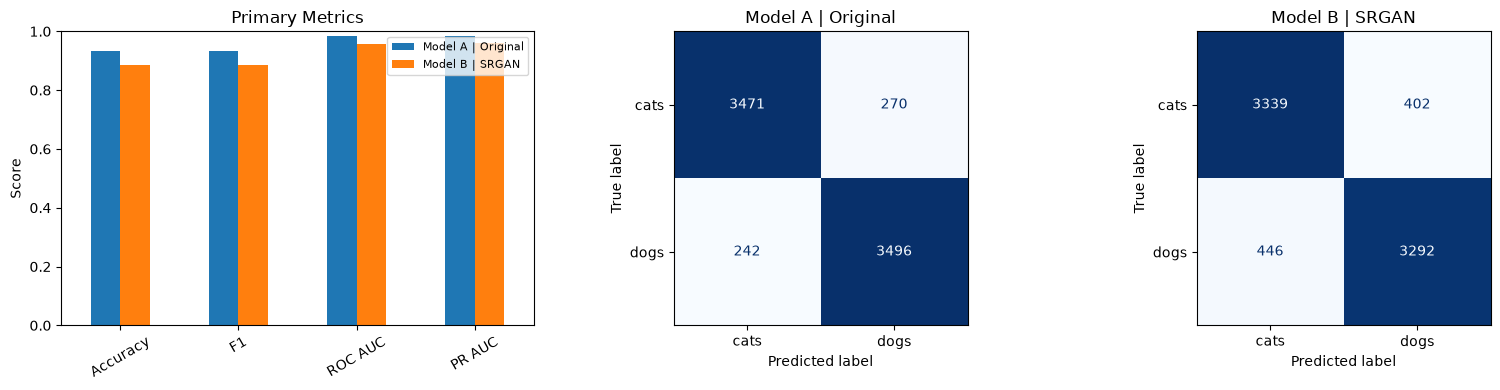

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

metric_plot = primary_results[['Accuracy', 'F1', 'ROC AUC', 'PR AUC']].T
metric_plot.plot(kind='bar', ax=axes[0], ylim=(0, 1))
axes[0].set_title('Primary Metrics')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(fontsize=8)

model_a_matrix = confusion_matrix(targets, model_a_original_predictions)
model_b_matrix = confusion_matrix(targets, model_b_srgan_predictions)

ConfusionMatrixDisplay(
    model_a_matrix,
    display_labels=CLASS_NAMES,
).plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Model A | Original')

ConfusionMatrixDisplay(
    model_b_matrix,
    display_labels=CLASS_NAMES,
).plot(ax=axes[2], cmap='Blues', colorbar=False)
axes[2].set_title('Model B | SRGAN')

plt.tight_layout()
plt.show()

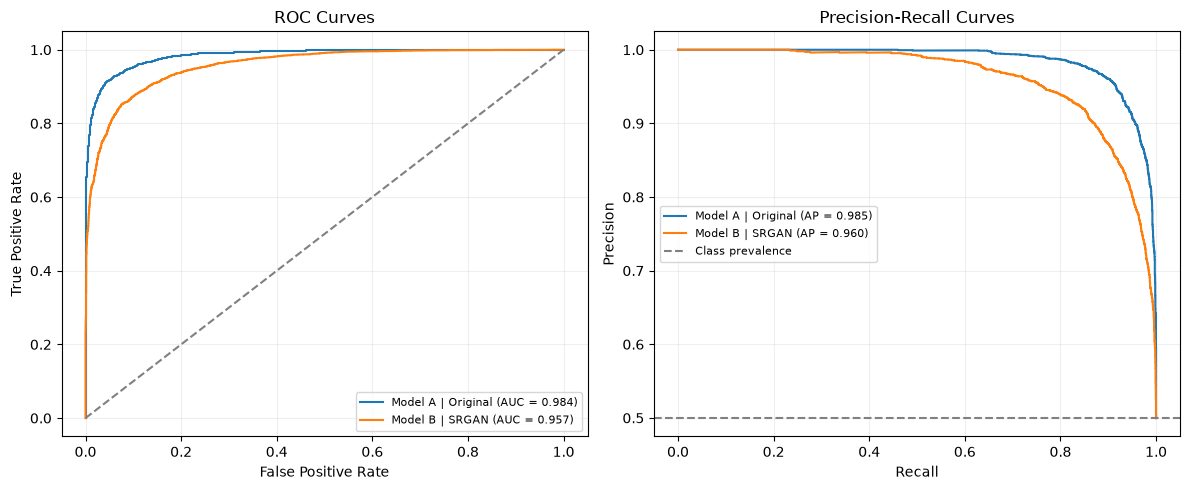

In [10]:
model_a_fpr, model_a_tpr, model_a_thresholds = roc_curve(
    targets,
    model_a_original_probabilities,
)
model_b_fpr, model_b_tpr, model_b_thresholds = roc_curve(
    targets,
    model_b_srgan_probabilities,
)

model_a_precision, model_a_recall, model_a_pr_thresholds = precision_recall_curve(
    targets,
    model_a_original_probabilities,
)
model_b_precision, model_b_recall, model_b_pr_thresholds = precision_recall_curve(
    targets,
    model_b_srgan_probabilities,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(
    model_a_fpr,
    model_a_tpr,
    label=f"Model A | Original (AUC = {model_a_original_metrics['ROC AUC']:.3f})",
)
axes[0].plot(
    model_b_fpr,
    model_b_tpr,
    label=f"Model B | SRGAN (AUC = {model_b_srgan_metrics['ROC AUC']:.3f})",
)
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_title('ROC Curves')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.2)

axes[1].plot(
    model_a_recall,
    model_a_precision,
    label=f"Model A | Original (AP = {model_a_original_metrics['PR AUC']:.3f})",
)
axes[1].plot(
    model_b_recall,
    model_b_precision,
    label=f"Model B | SRGAN (AP = {model_b_srgan_metrics['PR AUC']:.3f})",
)
axes[1].axhline(targets.mean(), linestyle='--', color='gray', label='Class prevalence')
axes[1].set_title('Precision-Recall Curves')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Class and Domain Effects

Class-level scores reveal whether one category is disproportionately affected. The cross-domain differences distinguish degradation caused by SRGAN reconstruction from gains caused by training Model B on that reconstructed image style.

In [11]:
class_rows = []

for class_index in range(len(CLASS_NAMES)):
    class_name = CLASS_NAMES[class_index]

    model_a_row = {
        'Pipeline': 'Model A | Original',
        'Class': class_name,
        'Precision': precision_score(
            targets,
            model_a_original_predictions,
            pos_label=class_index,
            zero_division=0,
        ),
        'Recall': recall_score(
            targets,
            model_a_original_predictions,
            pos_label=class_index,
            zero_division=0,
        ),
        'F1': f1_score(
            targets,
            model_a_original_predictions,
            pos_label=class_index,
            zero_division=0,
        ),
    }
    class_rows.append(model_a_row)

    model_b_row = {
        'Pipeline': 'Model B | SRGAN',
        'Class': class_name,
        'Precision': precision_score(
            targets,
            model_b_srgan_predictions,
            pos_label=class_index,
            zero_division=0,
        ),
        'Recall': recall_score(
            targets,
            model_b_srgan_predictions,
            pos_label=class_index,
            zero_division=0,
        ),
        'F1': f1_score(
            targets,
            model_b_srgan_predictions,
            pos_label=class_index,
            zero_division=0,
        ),
    }
    class_rows.append(model_b_row)

class_results = pd.DataFrame(class_rows)
class_results = class_results.set_index(['Pipeline', 'Class'])
display(class_results.round(4))

srgan_effect = model_a_srgan_metrics['Accuracy'] - model_a_original_metrics['Accuracy']
adaptation_gain = model_b_srgan_metrics['Accuracy'] - model_a_srgan_metrics['Accuracy']
model_b_domain_shift = model_b_original_metrics['Accuracy'] - model_b_srgan_metrics['Accuracy']
overall_difference = model_b_srgan_metrics['Accuracy'] - model_a_original_metrics['Accuracy']

domain_effects = pd.DataFrame(
    {
        'Difference': [
            srgan_effect * 100,
            adaptation_gain * 100,
            model_b_domain_shift * 100,
            overall_difference * 100,
        ]
    },
    index=[
        'SRGAN effect on Model A accuracy',
        'Model B adaptation gain on SRGAN accuracy',
        'Model B domain shift on original accuracy',
        'End-to-end Model B minus Model A accuracy',
    ],
)

print('Accuracy differences in percentage points')
display(domain_effects.round(2))

,,Precision,Recall,F1
Pipeline,Class,,,
Model A | Original,cats,0.9348,0.9278,0.9313
Model B | SRGAN,cats,0.8822,0.8925,0.8873
Model A | Original,dogs,0.9283,0.9353,0.9318
Model B | SRGAN,dogs,0.8912,0.8807,0.8859


Accuracy differences in percentage points


,Difference
SRGAN effect on Model A accuracy,-12.69
Model B adaptation gain on SRGAN accuracy,8.20
Model B domain shift on original accuracy,-0.79
End-to-end Model B minus Model A accuracy,-4.49


## Paired Uncertainty Analysis

Because both pipelines predict the same test records, paired bootstrap intervals quantify uncertainty in their score differences. McNemar's exact test evaluates whether the two pipelines have equal error rates using only records on which their correctness differs.

In [12]:
from scipy.stats import binomtest


rng = np.random.default_rng(SEED)
model_a_accuracy_samples = []
model_b_accuracy_samples = []
model_a_f1_samples = []
model_b_f1_samples = []
model_a_auc_samples = []
model_b_auc_samples = []

for sample_number in range(BOOTSTRAP_SAMPLES):
    sample_indices = rng.integers(0, len(targets), len(targets))
    sample_targets = targets[sample_indices]

    sample_a_probabilities = model_a_original_probabilities[sample_indices]
    sample_b_probabilities = model_b_srgan_probabilities[sample_indices]
    sample_a_predictions = sample_a_probabilities >= 0.5
    sample_b_predictions = sample_b_probabilities >= 0.5

    model_a_accuracy_samples.append(
        accuracy_score(sample_targets, sample_a_predictions)
    )
    model_b_accuracy_samples.append(
        accuracy_score(sample_targets, sample_b_predictions)
    )
    model_a_f1_samples.append(
        f1_score(sample_targets, sample_a_predictions, zero_division=0)
    )
    model_b_f1_samples.append(
        f1_score(sample_targets, sample_b_predictions, zero_division=0)
    )
    model_a_auc_samples.append(
        roc_auc_score(sample_targets, sample_a_probabilities)
    )
    model_b_auc_samples.append(
        roc_auc_score(sample_targets, sample_b_probabilities)
    )

model_a_accuracy_samples = np.array(model_a_accuracy_samples)
model_b_accuracy_samples = np.array(model_b_accuracy_samples)
model_a_f1_samples = np.array(model_a_f1_samples)
model_b_f1_samples = np.array(model_b_f1_samples)
model_a_auc_samples = np.array(model_a_auc_samples)
model_b_auc_samples = np.array(model_b_auc_samples)

bootstrap_rows = []
bootstrap_values = [
    ('Accuracy', model_a_accuracy_samples, model_b_accuracy_samples),
    ('F1', model_a_f1_samples, model_b_f1_samples),
    ('ROC AUC', model_a_auc_samples, model_b_auc_samples),
]

for metric_name, model_a_samples, model_b_samples in bootstrap_values:
    differences = model_b_samples - model_a_samples
    row = {
        'Metric': metric_name,
        'Model A': model_a_samples.mean(),
        'Model A Lower': np.percentile(model_a_samples, 2.5),
        'Model A Upper': np.percentile(model_a_samples, 97.5),
        'Model B': model_b_samples.mean(),
        'Model B Lower': np.percentile(model_b_samples, 2.5),
        'Model B Upper': np.percentile(model_b_samples, 97.5),
        'B - A': differences.mean(),
        'Difference Lower': np.percentile(differences, 2.5),
        'Difference Upper': np.percentile(differences, 97.5),
    }
    bootstrap_rows.append(row)

bootstrap_results = pd.DataFrame(bootstrap_rows)
bootstrap_results = bootstrap_results.set_index('Metric')
display(bootstrap_results.round(4))

model_a_correct = model_a_original_predictions == targets
model_b_correct = model_b_srgan_predictions == targets
both_correct = np.sum(model_a_correct & model_b_correct)
model_a_only_correct = np.sum(model_a_correct & ~model_b_correct)
model_b_only_correct = np.sum(~model_a_correct & model_b_correct)
both_wrong = np.sum(~model_a_correct & ~model_b_correct)

paired_counts = pd.DataFrame(
    [
        [both_correct, model_a_only_correct],
        [model_b_only_correct, both_wrong],
    ],
    index=['Model A correct', 'Model A wrong'],
    columns=['Model B correct', 'Model B wrong'],
)

mcnemar_result = binomtest(
    model_b_only_correct,
    model_a_only_correct + model_b_only_correct,
    p=0.5,
)

display(paired_counts)
print("McNemar's exact p-value:", round(mcnemar_result.pvalue, 6))

,Model A,Model A Lower,Model A Upper,Model B,Model B Lower,Model B Upper,B - A,Difference Lower,Difference Upper
Metric,,,,,,,,,
Accuracy,0.9314,0.9259,0.9373,0.8865,0.8798,0.8936,-0.0449,-0.0517,-0.0374
F1,0.9316,0.9259,0.9373,0.8858,0.8789,0.8933,-0.0458,-0.0527,-0.0382
ROC AUC,0.9841,0.9820,0.9861,0.9571,0.9533,0.9610,-0.0270,-0.0304,-0.0236


,Model B correct,Model B wrong
Model A correct,6385,582
Model A wrong,246,266


McNemar's exact p-value: 0.0


## Confidence and Threshold Diagnostics

Brier score and log loss in the metric table penalize poorly calibrated confidence. Reliability curves show calibration directly, while threshold curves show whether the comparison is unusually sensitive to the fixed 0.5 decision rule.

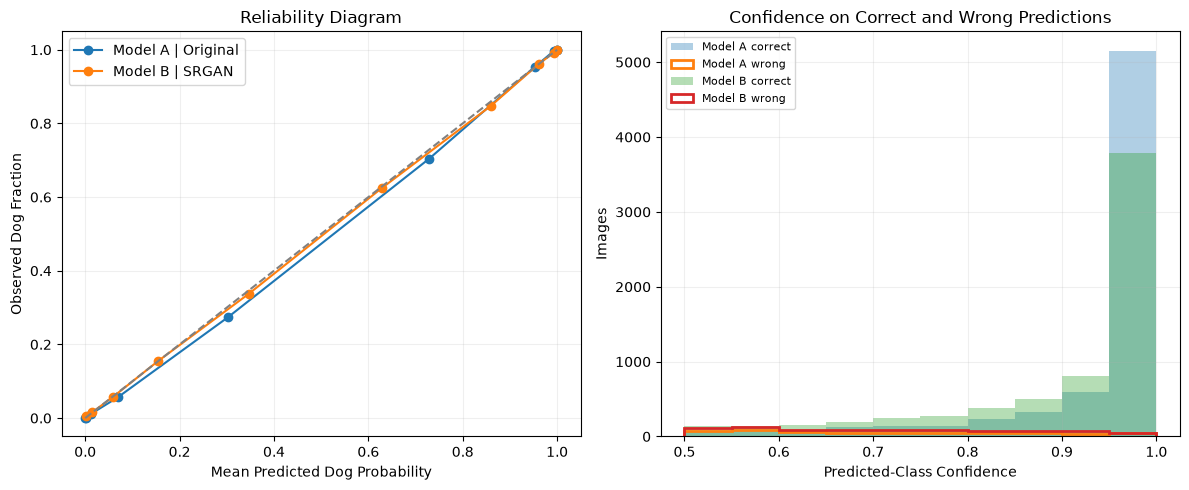

In [13]:
from sklearn.calibration import calibration_curve


model_a_observed, model_a_predicted = calibration_curve(
    targets,
    model_a_original_probabilities,
    n_bins=10,
    strategy='quantile',
)
model_b_observed, model_b_predicted = calibration_curve(
    targets,
    model_b_srgan_probabilities,
    n_bins=10,
    strategy='quantile',
)

model_a_confidence = np.maximum(
    model_a_original_probabilities,
    1 - model_a_original_probabilities,
)
model_b_confidence = np.maximum(
    model_b_srgan_probabilities,
    1 - model_b_srgan_probabilities,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(model_a_predicted, model_a_observed, marker='o', label='Model A | Original')
axes[0].plot(model_b_predicted, model_b_observed, marker='o', label='Model B | SRGAN')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_title('Reliability Diagram')
axes[0].set_xlabel('Mean Predicted Dog Probability')
axes[0].set_ylabel('Observed Dog Fraction')
axes[0].legend()
axes[0].grid(alpha=0.2)

bins = np.linspace(0.5, 1.0, 11)
axes[1].hist(
    model_a_confidence[model_a_correct],
    bins=bins,
    alpha=0.35,
    label='Model A correct',
)
axes[1].hist(
    model_a_confidence[~model_a_correct],
    bins=bins,
    histtype='step',
    linewidth=2,
    label='Model A wrong',
)
axes[1].hist(
    model_b_confidence[model_b_correct],
    bins=bins,
    alpha=0.35,
    label='Model B correct',
)
axes[1].hist(
    model_b_confidence[~model_b_correct],
    bins=bins,
    histtype='step',
    linewidth=2,
    label='Model B wrong',
)
axes[1].set_title('Confidence on Correct and Wrong Predictions')
axes[1].set_xlabel('Predicted-Class Confidence')
axes[1].set_ylabel('Images')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

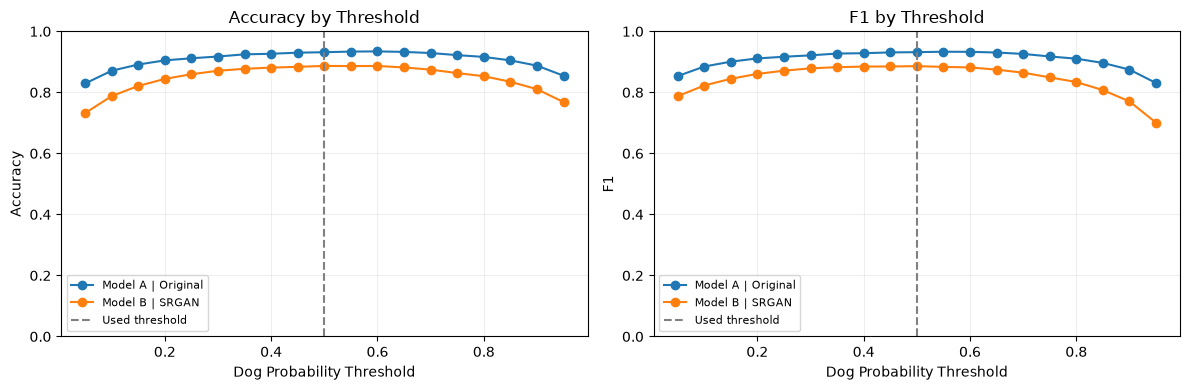

The reported test metrics use a threshold of 0.5.


In [14]:
thresholds = np.linspace(0.05, 0.95, 19)
model_a_threshold_accuracy = []
model_b_threshold_accuracy = []
model_a_threshold_f1 = []
model_b_threshold_f1 = []

for threshold in thresholds:
    model_a_threshold_predictions = model_a_original_probabilities >= threshold
    model_b_threshold_predictions = model_b_srgan_probabilities >= threshold

    model_a_threshold_accuracy.append(
        accuracy_score(targets, model_a_threshold_predictions)
    )
    model_b_threshold_accuracy.append(
        accuracy_score(targets, model_b_threshold_predictions)
    )
    model_a_threshold_f1.append(
        f1_score(targets, model_a_threshold_predictions, zero_division=0)
    )
    model_b_threshold_f1.append(
        f1_score(targets, model_b_threshold_predictions, zero_division=0)
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(thresholds, model_a_threshold_accuracy, marker='o', label='Model A | Original')
axes[0].plot(thresholds, model_b_threshold_accuracy, marker='o', label='Model B | SRGAN')
axes[0].axvline(0.5, linestyle='--', color='gray', label='Used threshold')
axes[0].set_title('Accuracy by Threshold')
axes[0].set_xlabel('Dog Probability Threshold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.2)
axes[0].legend(fontsize=8)

axes[1].plot(thresholds, model_a_threshold_f1, marker='o', label='Model A | Original')
axes[1].plot(thresholds, model_b_threshold_f1, marker='o', label='Model B | SRGAN')
axes[1].axvline(0.5, linestyle='--', color='gray', label='Used threshold')
axes[1].set_title('F1 by Threshold')
axes[1].set_xlabel('Dog Probability Threshold')
axes[1].set_ylabel('F1')
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.2)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()
print('The reported test metrics use a threshold of 0.5.')

## Paired Error Analysis

The examples below focus on records that Model A classifies correctly but the end-to-end Model B pipeline misses with high confidence. Showing the original and generated versions together helps connect numerical errors to visible reconstruction changes.

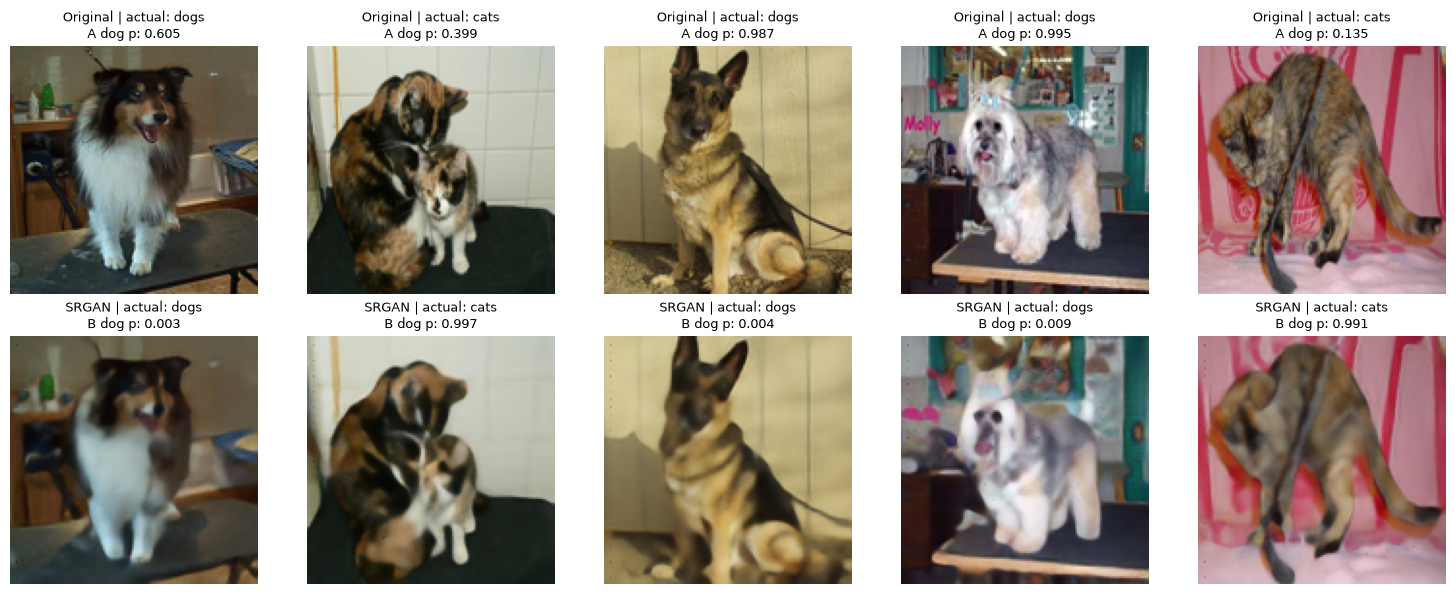

In [15]:
def display_image(image):
    image = image.detach().cpu()
    image = (image.clamp(-1, 1) + 1) / 2
    image = image.permute(1, 2, 0)
    return image


model_a_only_indices = np.flatnonzero(model_a_correct & ~model_b_correct)
model_b_error_confidence = model_b_confidence[model_a_only_indices]
sorted_positions = np.argsort(model_b_error_confidence)
sorted_positions = sorted_positions[::-1]
ranked_indices = model_a_only_indices[sorted_positions]
selected_indices = ranked_indices[:5]

if len(selected_indices) == 0:
    print('There are no records that only Model B misclassified.')
else:
    number_of_examples = len(selected_indices)
    fig, axes = plt.subplots(
        2,
        number_of_examples,
        figsize=(3 * number_of_examples, 6),
        squeeze=False,
    )

    for column in range(number_of_examples):
        test_index = int(selected_indices[column])
        low_resolution, original_image, label, index = test_dataset[test_index]

        low_resolution_batch = low_resolution.unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            generated_image = generator(low_resolution_batch).squeeze(0)

        actual_class = CLASS_NAMES[int(label.item())]
        model_a_probability = model_a_original_probabilities[test_index]
        model_b_probability = model_b_srgan_probabilities[test_index]

        axes[0, column].imshow(display_image(original_image))
        axes[0, column].set_title(
            f'Original | actual: {actual_class}\nA dog p: {model_a_probability:.3f}',
            fontsize=9,
        )
        axes[1, column].imshow(display_image(generated_image))
        axes[1, column].set_title(
            f'SRGAN | actual: {actual_class}\nB dog p: {model_b_probability:.3f}',
            fontsize=9,
        )
        axes[0, column].axis('off')
        axes[1, column].axis('off')

    plt.tight_layout()
    plt.show()

## Save Results

Save the complete metric, prediction, class-level, and uncertainty tables used in the comparison.

In [16]:
actual_labels = []
model_a_original_labels = []
model_a_srgan_labels = []
model_b_original_labels = []
model_b_srgan_labels = []

for target in targets:
    actual_labels.append(CLASS_NAMES[target])

for prediction in model_a_original_predictions:
    model_a_original_labels.append(CLASS_NAMES[prediction])

for prediction in model_a_srgan_predictions:
    model_a_srgan_labels.append(CLASS_NAMES[prediction])

for prediction in model_b_original_predictions:
    model_b_original_labels.append(CLASS_NAMES[prediction])

for prediction in model_b_srgan_predictions:
    model_b_srgan_labels.append(CLASS_NAMES[prediction])

prediction_table = pd.DataFrame({
    'image_path': test_table['image_path'],
    'actual': actual_labels,
    'model_a_original_probability_dog': model_a_original_probabilities,
    'model_a_original_predicted': model_a_original_labels,
    'model_a_srgan_probability_dog': model_a_srgan_probabilities,
    'model_a_srgan_predicted': model_a_srgan_labels,
    'model_b_original_probability_dog': model_b_original_probabilities,
    'model_b_original_predicted': model_b_original_labels,
    'model_b_srgan_probability_dog': model_b_srgan_probabilities,
    'model_b_srgan_predicted': model_b_srgan_labels,
})

all_results.to_csv(OUTPUT_DIR / 'model_comparison_metrics.csv')
class_results.to_csv(OUTPUT_DIR / 'class_level_metrics.csv')
bootstrap_results.to_csv(OUTPUT_DIR / 'bootstrap_intervals.csv')
prediction_table.to_csv(OUTPUT_DIR / 'test_predictions.csv', index=False)

metrics_json = all_results.to_dict(orient='index')
metrics_json = json.dumps(metrics_json, indent=2)
metrics_path = OUTPUT_DIR / 'model_comparison_metrics.json'
metrics_path.write_text(metrics_json, encoding='utf-8')

print('Comparison results saved to:', OUTPUT_DIR)

Comparison results saved to: C:\Users\Matt Shaver\OneDrive\Desktop\DSBA-6165-Sum-2026-Take-Home-Exam\outputs\model_comparison


## Interpretation

Summarize the end-to-end result, domain adaptation, class behavior, uncertainty, and confidence quality from the measured values.

In [17]:
model_a_accuracy = model_a_original_metrics['Accuracy']
model_b_accuracy = model_b_srgan_metrics['Accuracy']
accuracy_difference = model_b_accuracy - model_a_accuracy
adaptation_gain = model_b_srgan_metrics['Accuracy'] - model_a_srgan_metrics['Accuracy']
roc_auc_difference = model_b_srgan_metrics['ROC AUC'] - model_a_original_metrics['ROC AUC']
model_a_brier = model_a_original_metrics['Brier Score']
model_b_brier = model_b_srgan_metrics['Brier Score']

print('1. End-to-end comparison')
print('Model A accuracy:', round(model_a_accuracy, 4))
print('Model B accuracy:', round(model_b_accuracy, 4))
print('Accuracy difference in percentage points:', round(accuracy_difference * 100, 2))
print('ROC AUC difference:', round(roc_auc_difference, 4))

print('\n2. Effect of using a classifier trained for SRGAN images')
print('Model B gain over Model A on SRGAN images:', round(adaptation_gain * 100, 2))

print('\n3. Class-level recall')
for class_name in CLASS_NAMES:
    model_a_recall = class_results.loc[('Model A | Original', class_name), 'Recall']
    model_b_recall = class_results.loc[('Model B | SRGAN', class_name), 'Recall']
    recall_difference = model_b_recall - model_a_recall
    print(class_name.title())
    print('Model A recall:', round(model_a_recall, 4))
    print('Model B recall:', round(model_b_recall, 4))
    print('Difference:', round(recall_difference, 4))

print('\n4. Paired evidence and confidence quality')
print("McNemar's p-value:", round(mcnemar_result.pvalue, 6))
print('Model A Brier score:', round(model_a_brier, 4))
print('Model B Brier score:', round(model_b_brier, 4))

if accuracy_difference > 0:
    better_pipeline = 'Model B with SRGAN images'
else:
    better_pipeline = 'Model A with original images'

print('\nOverall conclusion:', better_pipeline, 'has the higher test accuracy.')

1. End-to-end comparison
Model A accuracy: 0.9315
Model B accuracy: 0.8866
Accuracy difference in percentage points: -4.49
ROC AUC difference: -0.027

2. Effect of using a classifier trained for SRGAN images
Model B gain over Model A on SRGAN images: 8.2

3. Class-level recall
Cats
Model A recall: 0.9278
Model B recall: 0.8925
Difference: -0.0353
Dogs
Model A recall: 0.9353
Model B recall: 0.8807
Difference: -0.0546

4. Paired evidence and confidence quality
McNemar's p-value: 0.0
Model A Brier score: 0.0487
Model B Brier score: 0.0815

Overall conclusion: Model A with original images has the higher test accuracy.
